In [2]:
import numpy as np
import matplotlib.pyplot as plt
import sklearn
import pandas as pd
import seaborn as sb

## Задача 1.
Генерирайте 1000 наблюдения над двумерни нормална случайна величина със средно $\mu_1=(0, 0)$ и $\mu_2=(4,8)$  и ковариационна матриц:

$$\Sigma = \begin{pmatrix} 10 & 3 \\ 3 & 1 \end{pmatrix}.$$

Начертайте графика, която показва данните като двумерни точки и също така правите, дефинирани от двата собствени вектора на извадъчната ковариоационната матрица.

In [3]:
N = 1000
X1 = np.random.multivariate_normal([0, 0], [[10, 3], [3, 1]], N)
X2 = np.random.multivariate_normal([1, 8], [[10, 3], [3, 1]], N)

In [4]:
def plot_pca(X):
    m = np.mean(X, axis=0)
    S = np.cov(X, rowvar=False)

    _, eigenvectors = np.linalg.eigh(S)

    plt.axline(m, m + eigenvectors[:, 0], color='g')
    plt.axline(m, m + eigenvectors[:, 1], color='r')
    plt.scatter(X[:, 0], X[:, 1])
    plt.axis('equal')
    plt.axhline(0, color='black', linewidth=0.7, linestyle='--')
    plt.axvline(0, color='black', linewidth=0.7, linestyle='--')
    plt.show()

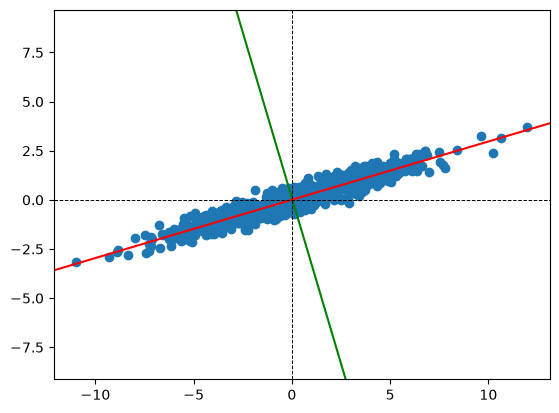

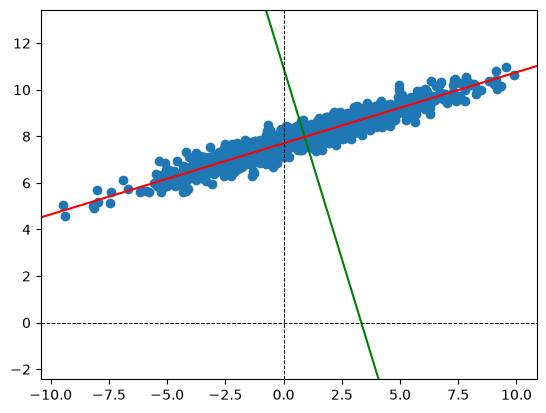

In [5]:
plot_pca(X1)
plot_pca(X2)

## Задача 2.
1. Използвайки библиотеката scikit-learn, направете PCA на данните и ги трансформирайте до едномерни.
2. Имплементирайте функция, която извършва PCA и трансформира данните към едномерни, изпозлвайки първата главна компонента. Сравнете данните с тези от scikit-learn
3. Разширете функцията да приема данни с произволна размерност и да приема аргумент `n_components`, който определя към колко мерни да се трансформират данните.

In [6]:
N = 1000
mu = np.random.rand(3)
sig = np.random.rand(3, 3)
sig = sig @ sig.T

X = np.random.multivariate_normal(mu, sig, N)

pca = sklearn.decomposition.PCA(n_components=1)

pca.fit(X)
X_pca = pca.transform(X)

print(X_pca[:5])

[[ 2.40722157]
 [ 0.29640837]
 [ 1.62471293]
 [-1.21326987]
 [-0.81768958]]


In [7]:
def pca(X, n_components=1):
    m = np.mean(X, axis=0)
    S = np.cov(X, rowvar=False)
    l, e = np.linalg.eigh(S)

    order = np.argsort(l, descending=True)
    l = l[order]
    e = e[:, order]

    # Обръщаме знака на всеки собствен вектор така че да сочи в положителната посока на най-голямата му компонента
    max_idx = np.argmax(np.abs(e), axis=0)
    max_val = e[max_idx, np.arange(e.shape[1])]
    sign = np.sign(max_val)
    e = e * sign

    Xt = (X - m) @ e[:, :n_components]

    return Xt

X_pca = pca(X, 1)

print(X_pca[:5])

[[ 2.40722157]
 [ 0.29640837]
 [ 1.62471293]
 [-1.21326987]
 [-0.81768958]]


In [8]:
X_pca = pca(X, 2)

print(X_pca[:5])

[[ 2.40722157  0.51261521]
 [ 0.29640837  0.43291968]
 [ 1.62471293 -0.42666976]
 [-1.21326987  0.47190466]
 [-0.81768958 -0.07569094]]


## Задача 3а.
1. Заредете данните от файла "data/Pizza.csv". Те съдържат данни за количеството на няколко параметъра в 100 грама пица заедно с типа (класа) на пицата. Вземете само колоните с предикторите. 
2. Начертайте scatterplots по двойки на предикторите (pairplot). Билхме ли спечелили от PCA вързху тези данни.
3. Начертайте графика на собствените стойности на ковариационната матрица на данните (scree plot). Изберете най-подходящия брой на компоненните, които да запазим след като направим PCA. Пресметнете каква част от вариацията би се описвала от трансформираните данни за всеки възможен избор на размерност.
4. Трансформирайте данните по главните им компоненти. Изберете първите главни компоненти спрямо избора от предишната задача.

In [9]:
data = pd.read_csv("data/Pizza.csv")
data.head()

,brand,id,mois,prot,fat,ash,sodium,carb,cal
0,A,14069,27.82,21.43,44.87,5.11,1.77,0.77,4.93
1,A,14053,28.49,21.26,43.89,5.34,1.79,1.02,4.84
2,A,14025,28.35,19.99,45.78,5.08,1.63,0.80,4.95
3,A,14016,30.55,20.15,43.13,4.79,1.61,1.38,4.74
4,A,14005,30.49,21.28,41.65,4.82,1.64,1.76,4.67


In [10]:
predictors = [c for c in data.columns if c not in ['brand', 'id']]
X = data[predictors]

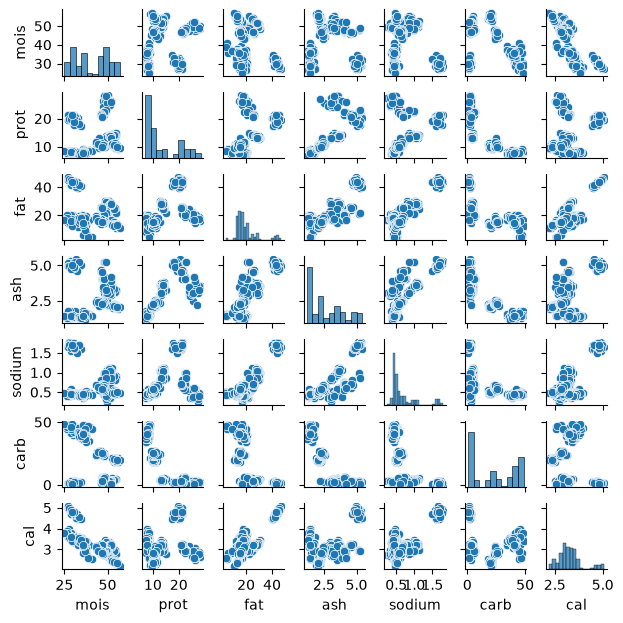

In [11]:
# Вижда се силна мултиколинеарност между част от променливите, това подсказва, че PCA може да се използваа за ортогонализация на данните.
sb.pairplot(X, height=0.9)

In [12]:
# При 3 главни компонента е обяснена приблизително 100% от вариацията
# Добавянето на 3-тия компонент допринася само 3% към обяснената вариация
def compute_scree_plot_and_explained_variance_plot(X):
    S = X.cov(ddof=1)

    l, e = np.linalg.eigh(S)

    order = np.argsort(l, descending=True)
    l = l[order]
    e = e[:, order]

    explained_var = l / np.sum(l)
    cum_explained_var = np.cumsum(explained_var)
    components = np.arange(1, len(l)+1)

    def add_point_labels(ax, x, y, lim=None, formatting='.2f', offset=(0, -15)):
        for i in range(len(x)):
            ax.annotate(f'{y[i]:{formatting}}', (x[i], y[i]), textcoords="offset points", xytext=offset)
            if lim is not None and i < len(y) - 1 and np.abs(y[i+1] - y[i]) < lim:
                break

    fig, ax = plt.subplots(1, 2, figsize=(10, 4), tight_layout=True)

    # Scree plot
    ax[0].plot(components, l, marker='o')
    add_point_labels(ax[0], components, l, offset=(5, 5), lim=0.2)

    ax[0].set_xlabel('Number of Principal Components')
    ax[0].set_ylabel('Eigenvalues')
    ax[0].set_title('Scree Plot')

    y_range = np.max(l) - np.min(l)
    ax[0].set_ylim(-0.1*y_range, np.max(l) + 0.1*y_range)

    # Explained variance plot
    ax[1].plot(components, cum_explained_var, marker='o')
    add_point_labels(ax[1], components, cum_explained_var, formatting='.0%', lim=1e-2)

    ax[1].set_xlabel('Number of Principal Components')
    ax[1].set_ylabel('Explained Variance')
    ax[1].set_title('Explained Variance Plot')

    y_range = np.max(cum_explained_var) - np.min(cum_explained_var)
    ax[1].set_ylim(np.min(cum_explained_var) - 0.1*y_range, 1 + 0.1*y_range)

    plt.show()

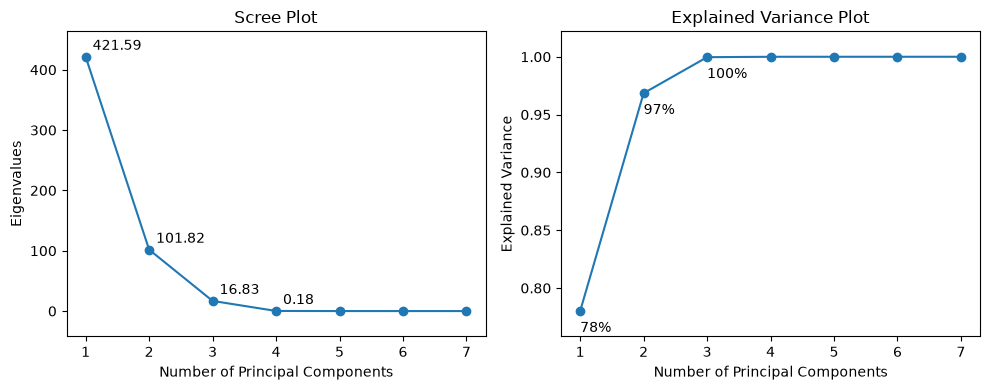

In [13]:
compute_scree_plot_and_explained_variance_plot(X)

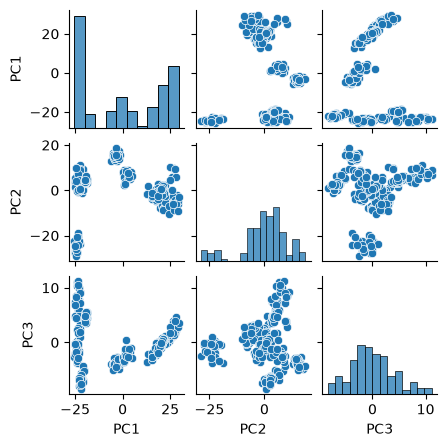

In [14]:
n_components = 3

pca = sklearn.decomposition.PCA(n_components=n_components)
X_pca = pca.fit_transform(X)

sb.pairplot(pd.DataFrame(X_pca, columns=[f'PC{i+1}' for i in range(n_components)]), height=1.5)

## ** Задача 3б.

1. Стандартизирайте данните от задача 3 а.
2. Повторете всички стъпки от задача 3 а.
3. Какъв извод можем да направим за PCA като сравним резултатите?

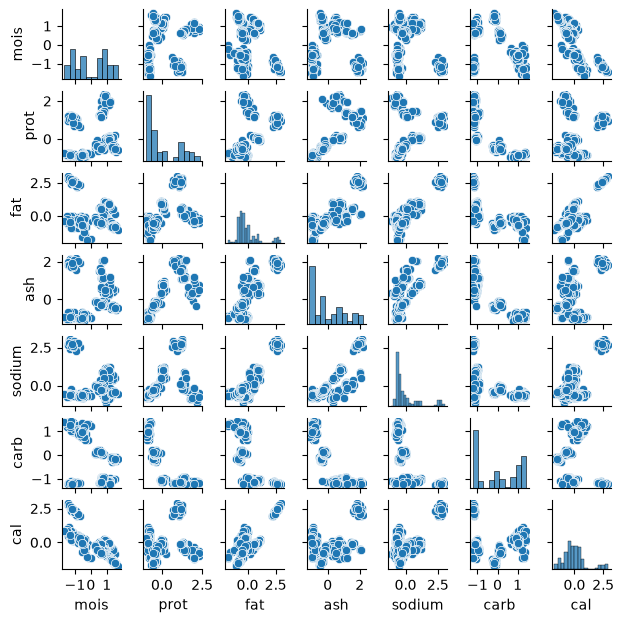

In [15]:
X_scaled = sklearn.preprocessing.StandardScaler().fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

# Тук също виждаме силна мултиколинеарност.
sb.pairplot(X_scaled, height=0.9)

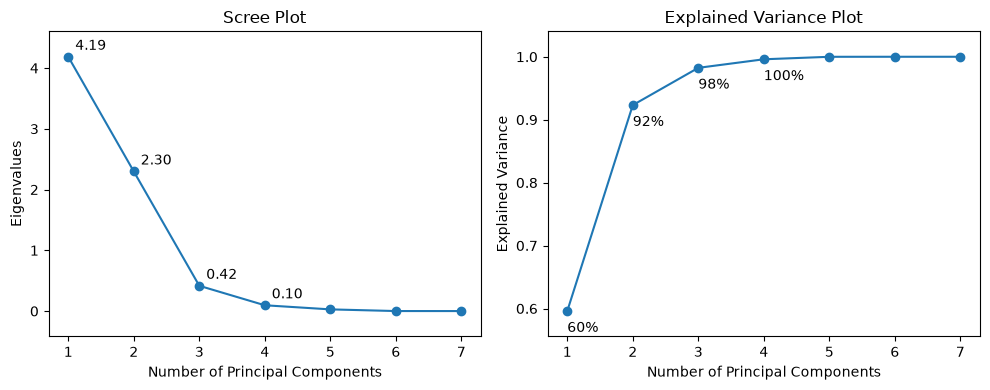

In [16]:
# PCA метода е чувствителен за мащаба на данните!
# 
# Обяснената вариация преди и след стандартизацията на данните е:
#   1ви компонент: 78% преди и 60% след
#   2ри компонент: 29% преди и 32% след
#   3ти компонент: 3% преди и 6% след
#   4ти компонент: 0% преди и 2% след
#
# Това е логично, избора на единиците в които се измерва една променлива влияе на вариацията и съответно на PCA резултатите. 
# Например, ако една и съща променлива се запише в метри вместо в километри, вариацията ще се увеличи значително и тя ще доминира PCA анализа.
compute_scree_plot_and_explained_variance_plot(X_scaled)

## ** Задача 4.
Заредете данните на MNIST като използвате `sklearn.datasets`. Направете PCA върху тези данни. Покажете първите 20 собствени вектора като изображения. Трансформитайте данните към главните компоненти и запазете първите 20 от тях. Колко е описаната вариация от 20-мерните трансфиормирани данни? Можем ли да интерпретираме собствените вектори и трансформираните данни?

[`sklearn.datasets.fetch_openml`](https://scikit-learn.org/stable/datasets/loading_other_datasets.html#downloading-datasets-from-the-openml-org-repository) предоставя интерфейс за сваляне на публично достъпни данни от [openml.org](https://www.openml.org/).

In [80]:
fetched = True

if not fetched:
    from sklearn.datasets import fetch_openml
    X, y = fetch_openml('mnist_784', as_frame=True, return_X_y=True)

    X.to_csv('data/X_mnist.csv')
    y.to_csv('data/y_mnist.csv')
else:
    X = pd.read_csv('data/X_mnist.csv', index_col=0)
    y = pd.read_csv('data/y_mnist.csv', index_col=0)


In [82]:
X.head()

,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,pixel10,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [83]:
y.head()


,class
0,5
1,0
2,4
3,1
4,9


Данните съдържат **784 (= 28 x 28)** пиксела в табуларен формат, където всеки ред съответства на определено, на ръка написано, число от **0** до **9**.

In [84]:
X.max(axis=None), X.min(axis=None)

(np.int64(255), np.int64(0))

Всяка стойност е число от 0 до 255 която определя цвета (grayscale). 

In [126]:
def plot_images(X, grid_size=(4, 4), dim=28, seed=None, ordered=False):
    pixels = X.reshape(len(X), dim, dim)

    if seed is not None:
        np.random.seed(seed)

    if ordered:
        indices = np.arange(np.min([len(X), grid_size[0] * grid_size[1]]))
    else:
        indices = np.random.choice(len(X), np.min([len(X), grid_size[0] * grid_size[1]]), replace=False)

    _, ax = plt.subplots(grid_size[0], grid_size[1], figsize=(grid_size[0]*2, grid_size[1]*2))

    for i, idx in enumerate(indices):
        row = i // grid_size[1]
        col = i % grid_size[1]
        ax[row, col] = sb.heatmap(pixels[idx], cbar=False, ax=ax[row, col])
        ax[row, col].set_aspect('equal')
        ax[row, col].set_xticks([])
        ax[row, col].set_yticks([])

    plt.show()

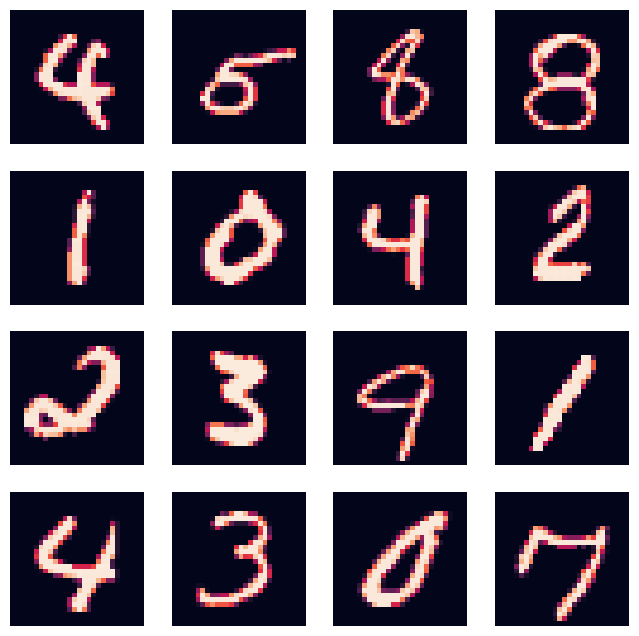

In [124]:
plot_images(X.to_numpy())

Сега ще трансформираме данните с PCA и ще изобразим първите 20 компоненти като изображения.

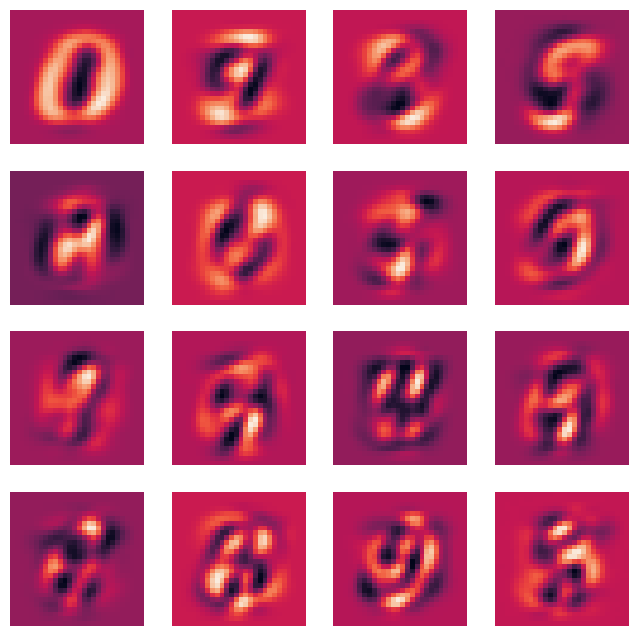

In [127]:
pca = sklearn.decomposition.PCA(n_components=20)
X_pca = pca.fit_transform(X)

plot_images(pca.components_, ordered=True)

Собствените вектори съвсем ясно наподобяват числа. Възможна интерпретация е, че всеки от векторите съответства на определен стил на писане и число. Когато се проектират оригиналните данни върху собствените вектори, ще имаме голяма стойност ако има съответствие между определено число, и числото/стила който измерва вектора.

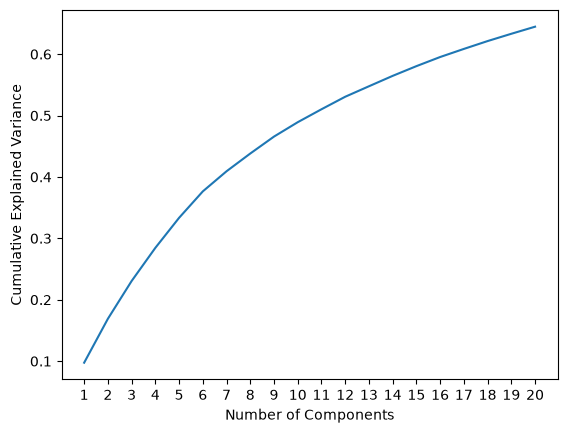

In [118]:
cum_explained_variance = np.cumsum(pca.explained_variance_ratio_)
x = np.arange(1, len(cum_explained_variance) + 1)

plt.plot(x, cum_explained_variance)
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.xticks(x)
plt.show()